# 1. Overview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FMT = lambda x, _: f'{x:,.0f}'

In [ ]:
df = pd.read_csv("D:/vinuni_datathon2026/vinuni_datathon2026/raw_datasets/products.csv")
df

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406
...,...,...,...,...,...,...,...,...
2407,1260,VietMode MP-28,Casual,Activewear,S,red,4603.340000,2553.933032
2408,1261,VietMode MP-29,Casual,Activewear,M,black,5983.876433,4653.660702
2409,1262,VietMode MP-30,Casual,Activewear,L,orange,5983.876433,5684.682611
2410,1263,VietMode MP-31,Casual,Activewear,XL,blue,5984.370000,5685.151500


## Data dictionary

| Cột          | Kiểu  | Mô tả                              |
|--------------|-------|------------------------------------|
| product_id   | int   | Khoá chính                         |
| product_name | str   | Tên sản phẩm                       |
| category     | str   | Danh mục sản phẩm                  |
| segment      | str   | Phân khúc thị trường của sản phẩm  |
| size         | str   | Kích cỡ sản phẩm                   |
| color        | str   | Nhãn màu sản phẩm                  |
| price        | float | Giá bán lẻ                         |
| cogs         | float | Giá vốn hàng bán                   |

> **Ràng buộc:** `cogs < price` với mọi sản phẩm.


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 242.7 KB


In [ ]:
df.shape

(2412, 8)

In [ ]:
df.describe()

,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000


In [ ]:
df.describe(include = 'object')

,product_name,category,segment,size,color
count,2412,2412,2412,2412,2412
unique,2172,4,8,4,10
top,VietMode RP-01,Streetwear,Activewear,S,black
freq,3,1320,598,603,242


## Tổng quan Dataset `products`

### 1. Cấu trúc chung
- Dataset gồm **2.412 sản phẩm** với **8 cột**, bao gồm 1 khoá chính số nguyên (`product_id`),
  5 cột định tính (`str`) và 2 cột định lượng (`float64`).
- **Không có giá trị thiếu (null)** ở bất kỳ cột nào → dữ liệu sạch về mặt completeness.

---

### 2. Nhận xét từng cột

| Cột | Nhận xét |
|---|---|
| `product_id` | Khoá chính dạng số nguyên, không có giá trị thiếu. Cần kiểm tra tính duy nhất. |
| `product_name` | 2.412 bản ghi nhưng chỉ có **2.172 tên duy nhất** → tồn tại **240 tên trùng lặp**. Tên phổ biến nhất là `VietMode RP-01` (xuất hiện 3 lần). Có thể là các biến thể màu/size khác nhau của cùng một dòng sản phẩm. |
| `category` | Chỉ có **4 danh mục**, trong đó **Streetwear chiếm ưu thế** với 1.320/2.412 sản phẩm (~54.7%). |
| `segment` | **8 phân khúc** thị trường, phổ biến nhất là **Activewear** (598 sản phẩm, ~24.8%). Phân bố tương đối đa dạng. |
| `size` | **4 kích cỡ** (S, M, L, XL), trong đó **S** là phổ biến nhất (603 sản phẩm, ~25%) — phân bố khá đều giữa các size. |
| `color` | **10 màu** khác nhau, **black** là màu phổ biến nhất (242 sản phẩm, ~10%) — phân bố tương đối đồng đều. |
| `price` | Giá bán lẻ dạng `float64`. Ví dụ dao động từ ~9.500 đến ~15.900 VNĐ trong mẫu đầu. |
| `cogs` | Giá vốn hàng bán, **luôn nhỏ hơn `price`** theo ràng buộc dữ liệu → biên lợi nhuận gộp dương với mọi sản phẩm. |

---

### 3. Lưu ý phân tích
- **Tên sản phẩm trùng**: Cần xác định xem các bản ghi trùng tên có phải là biến thể (khác màu, size)
  hay là dữ liệu nhập liệu lỗi.
- **Mất cân bằng danh mục**: `Streetwear` chiếm hơn 50% → cần lưu ý khi phân tích theo `category`.
- **Ràng buộc `cogs < price`**: Nên kiểm tra lại bằng code để xác nhận toàn bộ 2.412 bản ghi đều thoả mãn.


# 2. Check quality & Preprocessing

In [ ]:
# Kiểm tra ràng buộc cogs < price
df.loc[df["cogs"] >= df["price"]]

,product_id,product_name,category,segment,size,color,price,cogs


Ràng buộc `cogs` < `price` thỏa mãn

In [ ]:
# Kiếm tra tính unique của cột khóa chính
df["product_id"].duplicated().sum()

np.int64(0)

Kiểm tra xem các bản ghi có cùng `product_name` nhưng khác `product_ids` có khác biến thể (như`size` hay `color`) gì không

In [ ]:
df.groupby('product_name') \
  .filter(lambda x: len(x) > 1) \
  .groupby('product_name')['product_id'] \
  .apply(list) \
  .reset_index() \
  .rename(columns={'product_id': 'product_ids'}) \
  .sort_values('product_name')

,product_name,product_ids
0,LotusWear UE-01,"[280, 380]"
1,LotusWear UE-02,"[281, 381]"
2,LotusWear UE-03,"[282, 382]"
3,LotusWear UE-04,"[283, 383]"
4,LotusWear UE-05,"[284, 384]"
...,...,...
181,VietMode RS-01,"[1563, 1663]"
182,VietMode RS-02,"[1564, 1664]"
183,VietMode RS-03,"[1565, 1665]"
184,VietMode RS-04,"[1566, 1666]"


Có 186 `product_name` xuất hiện từ **2-3 lần**. Cần kiểm tra xem các product này có cùng biến thể như `category`, `size`, `color`, ... không

In [ ]:
df.loc[df["product_id"].isin([280, 380])]

,product_id,product_name,category,segment,size,color,price,cogs
645,280,LotusWear UE-01,Streetwear,Performance,S,red,12596.850000,11967.007500
745,380,LotusWear UE-01,Streetwear,Performance,S,red,34.036218,21.343813


In [ ]:
df.loc[df["product_id"].isin([1362, 1462, 1562])]

,product_id,product_name,category,segment,size,color,price,cogs
2179,1362,VietMode RP-54,Outdoor,Activewear,L,orange,4524.502500,4298.277375
2279,1462,VietMode RP-54,Outdoor,Activewear,L,orange,31.490479,19.720236
2379,1562,VietMode RP-54,Outdoor,Activewear,L,orange,4970.070000,2879.658558


In [ ]:
df.loc[df["product_name"] == "VietMode RS-04"]

,product_id,product_name,category,segment,size,color,price,cogs
1668,1566,VietMode RS-04,Outdoor,Premium,L,green,4467.960000,3904.103448
1768,1666,VietMode RS-04,Outdoor,Premium,L,green,2847.542727,2029.158947


In [ ]:
variant_cols = ['category', 'segment', 'size', 'color']

# Với mỗi product_name trùng, đếm số giá trị unique của từng cột biến thể
dup_groups = df[df.duplicated(subset='product_name', keep=False)] \
               .groupby('product_name')[variant_cols] \
               .nunique()

# Nếu tất cả == 1 → các bản ghi cùng tên GIỐNG NHAU hoàn toàn về biến thể
print("Có nhóm nào khác biến thể không?")
print((dup_groups > 1).any(axis=1).value_counts())



Có nhóm nào khác biến thể không?
False    186
Name: count, dtype: int64


Qua kiểm tra, dataset có **186 `product_name` xuất hiện từ 2–3 lần**, tương ứng với **426 bản ghi** — chiếm khoảng **17.7%** tổng số dòng.

Cụ thể:
- 132 tên xuất hiện **2 lần**
- 54 tên xuất hiện **3 lần**

**Kiểm tra biến thể:** Với tất cả 186 nhóm trùng tên, các thuộc tính mô tả sản phẩm (`category`, `segment`, `size`, `color`) đều **hoàn toàn giống nhau** giữa các bản ghi trong cùng nhóm.

**Kết luận:** Đây **không phải** là các biến thể sản phẩm khác nhau (ví dụ: cùng tên nhưng khác size), mà là các bản ghi **bị nhập trùng lặp** — chỉ khác nhau ở `product_id`, `price` và `cogs`.


Đặc biệt, một số nhóm có
`price`/`cogs` lệch bất thường (ví dụ: `VietMode RP-54` có bản ghi `price = 31.49` trong khi
các bản ghi cùng tên có giá ~4.500–4.970), cho thấy khả năng **sai sót khi nhập số liệu**.


In [ ]:
# Tập product_id xuất hiện trong từng bảng
ids_order     = set(order_items["product_id"].unique())
ids_returns   = set(returns["product_id"].unique())
ids_inventory = set(inventory["product_id"].unique())
ids_reviews   = set(reviews["product_id"].unique())
all_ids_in_tables = ids_order | ids_returns | ids_inventory | ids_reviews

# Mask: các bản ghi thuộc product_name có nhiều product_id
dup_mask = df.duplicated(subset="product_name", keep=False)

# Điều kiện xóa:
# - Thuộc nhóm trùng (dup_mask = True) VÀ product_id không có trong bất kỳ bảng nào
mask_remove = dup_mask & ~df["product_id"].isin(all_ids_in_tables)

before = len(df)
print(f"Số bản ghi bị xóa: {mask_remove.sum()}")
print(df[mask_remove][["product_id", "product_name"]].to_string())

df = df[~mask_remove].reset_index(drop=True)
print(f"\nTrước: {before} | Sau: {len(df)}")


Số bản ghi bị xóa: 72
      product_id      product_name
7            543  SaigonFlex UC-08
22           558  SaigonFlex UC-23
24           560  SaigonFlex UC-25
45           582  SaigonFlex UC-47
47           584  SaigonFlex UC-49
50           587  SaigonFlex UC-52
126          664  SaigonFlex UC-29
127          665  SaigonFlex UC-30
135          673  SaigonFlex UC-38
139          677  SaigonFlex UC-42
140          678  SaigonFlex UC-43
141          679  SaigonFlex UC-44
142          680  SaigonFlex UC-45
155          693  SaigonFlex UC-58
646          283   LotusWear UE-04
647          284   LotusWear UE-05
648          285   LotusWear UE-06
649          286   LotusWear UE-07
743          380   LotusWear UE-01
744          381   LotusWear UE-02
751          397  SaigonFlex UM-02
753          399  SaigonFlex UM-04
765          411  SaigonFlex UM-16
861          507  SaigonFlex UM-12
863          509  SaigonFlex UM-14
1763        1663    VietMode RS-01
1764        1664    VietMode RS-0

In [ ]:
# # Flag bản ghi có price lệch quá xa median của nhóm (> 50%)
# df['price_median_group'] = df.groupby('product_name')['price'].transform('median')
# df['is_price_anomaly'] = (df['price'] / df['price_median_group']).lt(0.5) | \
#                          (df['price'] / df['price_median_group']).gt(2.0)
# print(f"Số bản ghi bất thường: {df['is_price_anomaly'].sum()}")
# df_clean = df[~df['is_price_anomaly']].drop_duplicates(subset='product_name', keep='first')

In [ ]:
# Kiểm tra giá trị hợp lệ của cột categorical (typo, khoảng trắng thừa...)
for col in ['category', 'segment', 'size', 'color']:
    print(f"\n{col}:", df[col].unique())


category: <ArrowStringArray>
['Streetwear', 'Casual', 'Outdoor', 'GenZ']
Length: 4, dtype: str

segment: <ArrowStringArray>
[   'Everyday', 'Performance',    'Balanced',    'Standard', 'All-weather',
     'Premium',      'Trendy',  'Activewear']
Length: 8, dtype: str

size: <ArrowStringArray>
['S', 'M', 'L', 'XL']
Length: 4, dtype: str

color: <ArrowStringArray>
[ 'green', 'silver',   'pink', 'yellow',    'red',  'black', 'orange',
  'white', 'purple',   'blue']
Length: 10, dtype: str


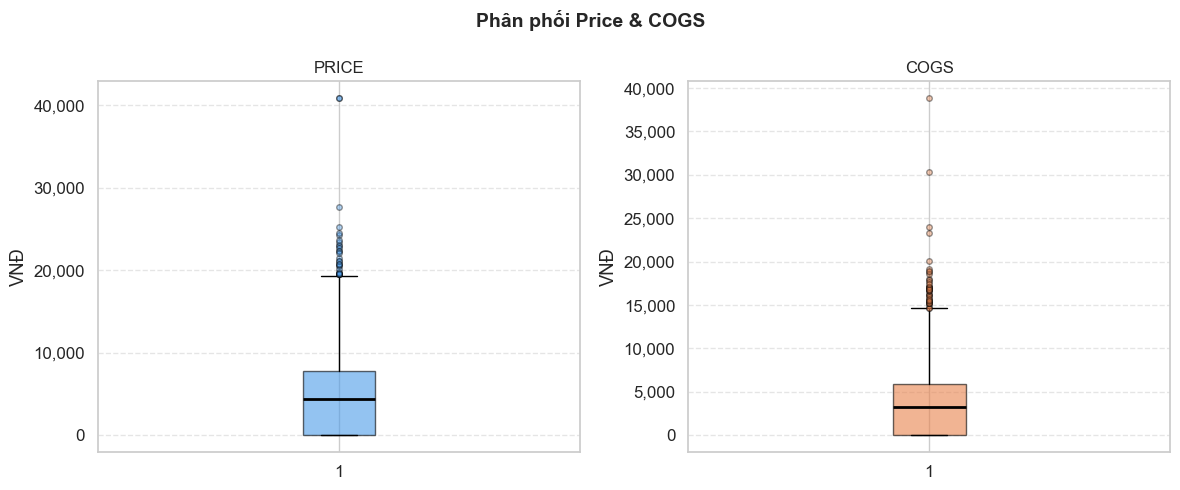

In [ ]:
# Kiểm tra outlier cho price và cogs
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Phân phối Price & COGS', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['price', 'cogs'], ['#4C9BE8', '#E8824C']):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor=color, alpha=0.4, markersize=4))
    ax.set_title(col.upper(), fontsize=12)
    ax.set_ylabel('VNĐ')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
for col in ['price', 'cogs']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(out)} outlier | lower={lower:,.1f} | upper={upper:,.1f}")


price: 29 outlier | lower=-11,542.9 | upper=19,400.6
cogs: 37 outlier | lower=-8,718.6 | upper=14,627.5


In [ ]:
df.to_csv("D:/vinuni_datathon2026/vinuni_datathon2026/cleaned_datasets/products_cleaned.csv", index=False)

# 3. EDA

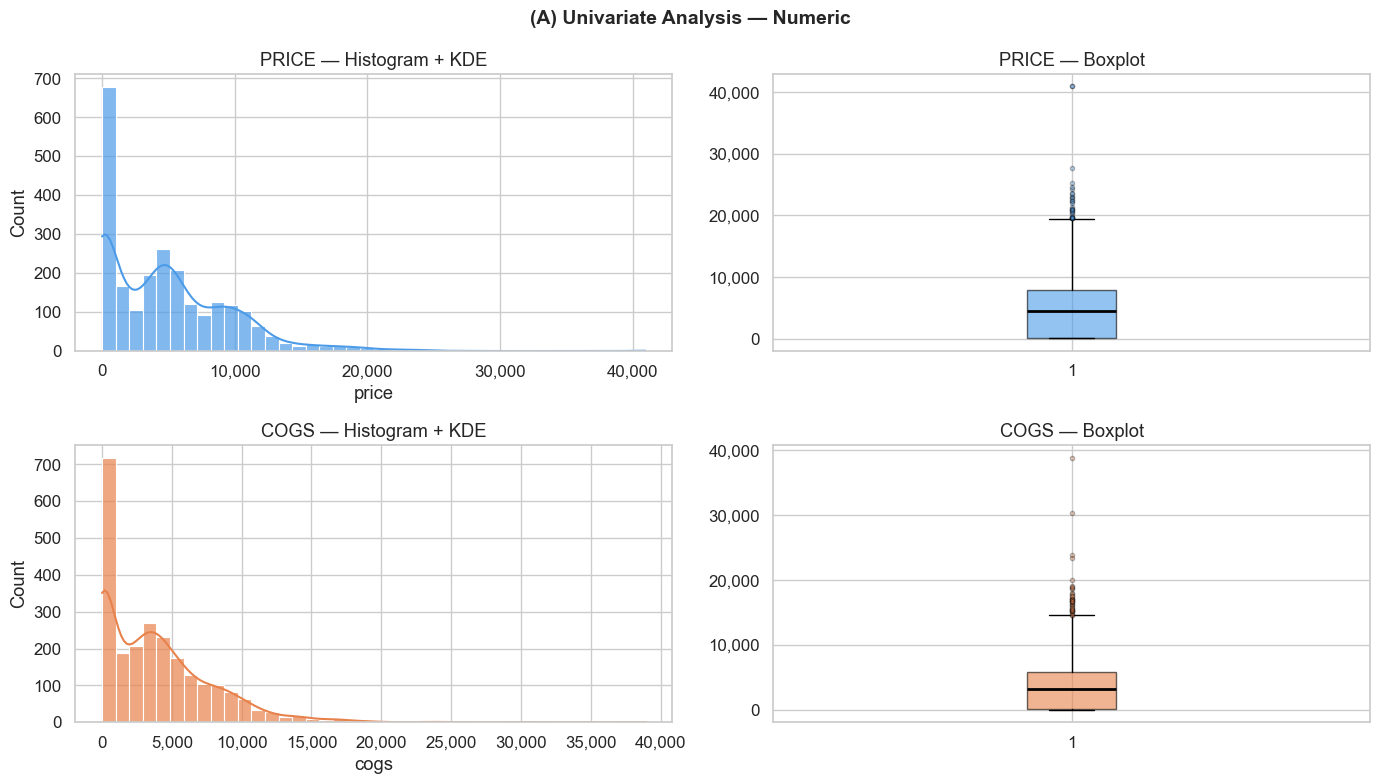


 PRICE
   Skewness : 1.3278  (right-skewed)
   Kurtosis : 3.5099
   KS-test  : stat=0.1504, p=8.4286e-48  → NOT normal 

 COGS
   Skewness : 1.4860  (right-skewed)
   Kurtosis : 4.6641
   KS-test  : stat=0.1585, p=4.6468e-53  → NOT normal 


In [ ]:
num_cols = ['price', 'cogs']
colors   = ['#4C9BE8', '#E8824C']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('(A) Univariate Analysis — Numeric', fontsize=14, fontweight='bold')

for i, (col, c) in enumerate(zip(num_cols, colors)):
    # Histogram + KDE
    ax = axes[i, 0]
    sns.histplot(df[col], kde=True, ax=ax, color=c, bins=40, alpha=0.7)
    ax.set_title(f'{col.upper()} — Histogram + KDE')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(FMT))

    # Boxplot
    ax = axes[i, 1]
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor=c, alpha=0.3, markersize=3))
    ax.set_title(f'{col.upper()} — Boxplot')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(FMT))

plt.tight_layout()
plt.show()

# Skewness, Kurtosis, KS-test
print("=" * 55)
for col in num_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    ks_stat, ks_p = stats.kstest(
        (df[col] - df[col].mean()) / df[col].std(), 'norm'
    )
    print(f"\n {col.upper()}")
    print(f"   Skewness : {skew:.4f}  {'(right-skewed)' if skew>0.5 else '(left-skewed)' if skew<-0.5 else '(symmetric)'}")
    print(f"   Kurtosis : {kurt:.4f}")
    print(f"   KS-test  : stat={ks_stat:.4f}, p={ks_p:.4e}  → {'NOT normal ' if ks_p<0.05 else 'Normal '}")
print("=" * 55)

# ── Insight ──────────────────────────────────────────────
# Kiểm tra xem price/cogs có phân phối chuẩn không,
# phục vụ quyết định dùng parametric hay non-parametric test.


Cả `price` và `cogs` đều có phân phối **lệch phải (right-skewed)**:
- `price`: skewness = **1.33**, kurtosis = **3.51**
- `cogs` : skewness = **1.49**, kurtosis = **4.66**
Kiểm định **Kolmogorov-Smirnov** bác bỏ giả thuyết phân phối chuẩn với p ≈ 0
→ cả hai biến đều **không tuân theo phân phối chuẩn**.
Quan sát từ biểu đồ, phần lớn sản phẩm tập trung ở mức giá thấp,
trong khi một số ít sản phẩm có giá rất cao (outlier phía phải).
> **Hệ quả:** Các kiểm định thống kê tiếp theo cần dùng phương pháp
> **phi tham số** (Kruskal-Wallis thay vì ANOVA, Spearman thay vì Pearson).

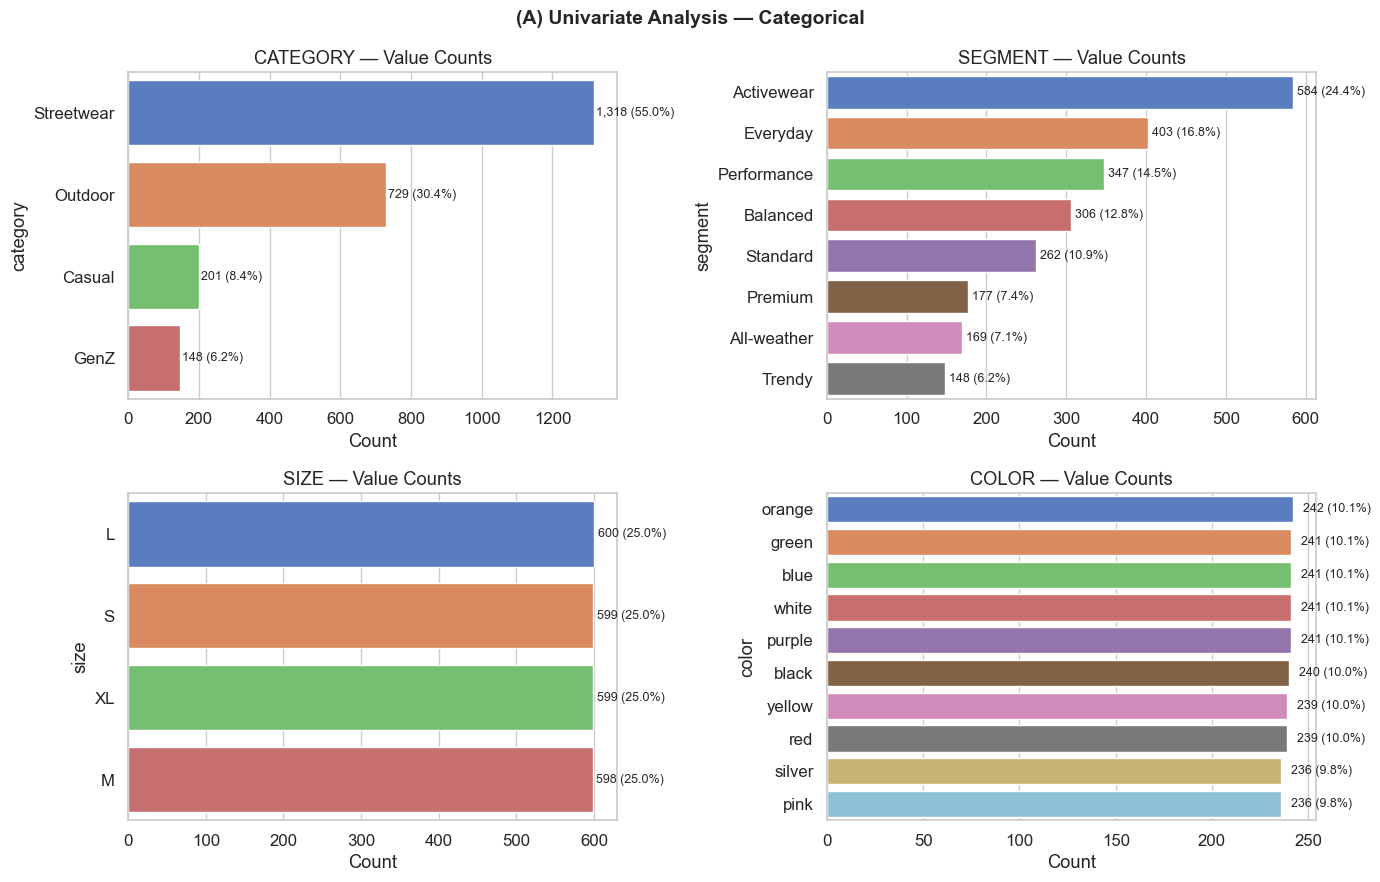


category:
category
Streetwear    1318
Outdoor        729
Casual         201
GenZ           148

segment:
segment
Activewear     584
Everyday       403
Performance    347
Balanced       306
Standard       262
Premium        177
All-weather    169
Trendy         148

size:
size
L     600
S     599
XL    599
M     598

color:
color
orange    242
green     241
blue      241
white     241
purple    241
black     240
yellow    239
red       239
silver    236
pink      236


In [ ]:
cat_cols = ['category', 'segment', 'size', 'color']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('(A) Univariate Analysis — Categorical', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax,
                palette='muted', orient='h')
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
    ax.set_title(f'{col.upper()} — Value Counts')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col}:\n{df[col].value_counts().to_string()}")


**`Category`:** Phân bố **mất cân bằng rõ rệt** — `Streetwear` chiếm **54.7%**,
gần gấp đôi `Outdoor` (30.8%), trong khi `Casual` và `GenZ` chỉ chiếm ~15% còn lại.
Cần lưu ý khi phân tích theo category để tránh bias.

**`Segment`:** Phân bố tương đối đa dạng với 8 nhóm. `Activewear` dẫn đầu (24.8%),
nhưng không nhóm nào chiếm quá 25% → ít mất cân bằng hơn category.

**`Size`:** Phân bố **hoàn toàn đều** — mỗi size (S/M/L/XL) có đúng **603 sản phẩm (25%)**.
Đây là dấu hiệu dataset được thiết kế có chủ ý, không phản ánh nhu cầu thực tế.

**`Color`:** Tương tự size, 10 màu phân bố **gần như đồng đều** (~10% mỗi màu).
`black` và `orange` nhỉnh hơn 1 đơn vị so với các màu còn lại — không đáng kể.

> **Tóm lại:** `size` và `color` có phân phối đều nhân tạo (likely by design),
> trong khi `category` có sự mất cân bằng đáng kể cần xử lý khi modeling.

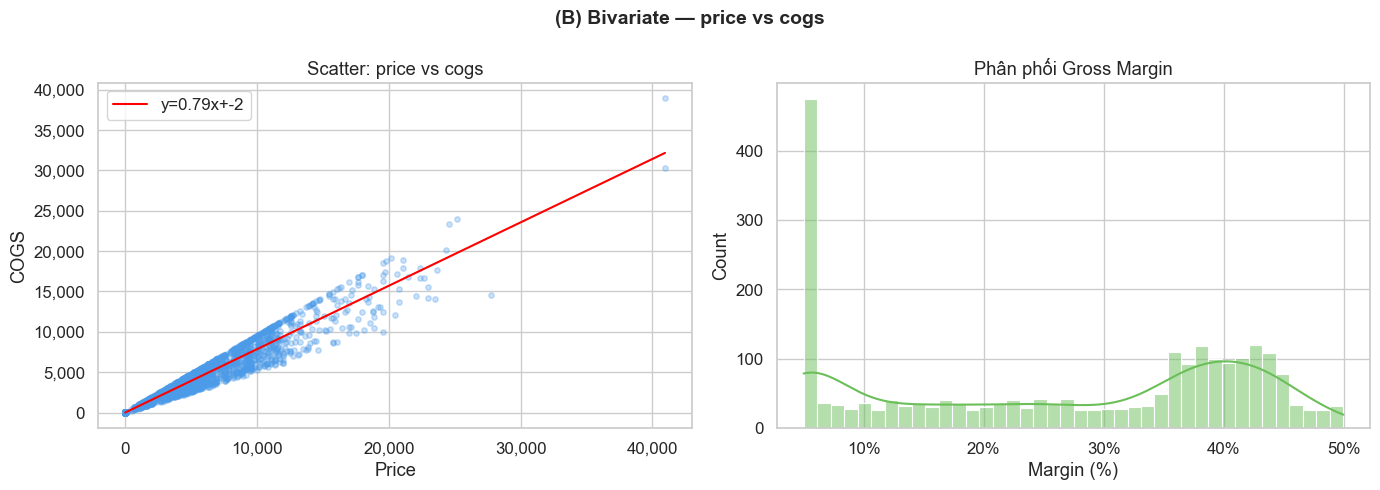

Pearson  r = 0.9670, p = 0.0000e+00
Spearman r = 0.9806, p = 0.0000e+00

Margin  mean=26.52%  std=15.12%  min=5.00%  max=49.96%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('(B) Bivariate — price vs cogs', fontsize=14, fontweight='bold')

# Scatter
ax = axes[0]
ax.scatter(df['price'], df['cogs'], alpha=0.3, s=15, color='#4C9BE8')
# Đường hồi quy
m, b = np.polyfit(df['price'], df['cogs'], 1)
x_range = np.linspace(df['price'].min(), df['price'].max(), 100)
ax.plot(x_range, m * x_range + b, color='red', lw=1.5, label=f'y={m:.2f}x+{b:.0f}')
ax.set_xlabel('Price'); ax.set_ylabel('COGS')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(FMT))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(FMT))
ax.set_title('Scatter: price vs cogs')
ax.legend()

# Margin distribution
df['gross_profit'] = df['price'] - df['cogs']
df['margin']       = df['gross_profit'] / df['price']
ax = axes[1]
sns.histplot(df['margin'], kde=True, ax=ax, color='#6BBF59', bins=40)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Phân phối Gross Margin')
ax.set_xlabel('Margin (%)')

plt.tight_layout()
plt.show()

# Correlation
pearson_r, pearson_p   = stats.pearsonr(df['price'], df['cogs'])
spearman_r, spearman_p = stats.spearmanr(df['price'], df['cogs'])
print(f"Pearson  r = {pearson_r:.4f}, p = {pearson_p:.4e}")
print(f"Spearman r = {spearman_r:.4f}, p = {spearman_p:.4e}")
print(f"\nMargin  mean={df['margin'].mean():.2%}  std={df['margin'].std():.2%}  "
      f"min={df['margin'].min():.2%}  max={df['margin'].max():.2%}")



**Tương quan:** `price` và `cogs` có tương quan **rất mạnh**:
- Pearson r = **0.967**, Spearman r = **0.981** (p ≈ 0)
- Đường hồi quy `cogs ≈ 0.79 × price` → trung bình giá vốn chiếm ~79% giá bán.

**Gross Margin:** Biên lợi nhuận gộp dao động khá rộng:

| Chỉ số | Giá trị |
|--------|---------|
| Mean   | 26.59%  |
| Std    | 15.11%  |
| Min    | 5.00%   |
| Max    | 49.96%  |

Biểu đồ phân phối margin cho thấy **2 cụm rõ rệt**:
- Cụm 1: margin thấp ~**5–10%** (số lượng lớn) — sản phẩm có biên lợi nhuận mỏng.
- Cụm 2: margin cao ~**30–50%** — sản phẩm có biên lợi nhuận tốt.


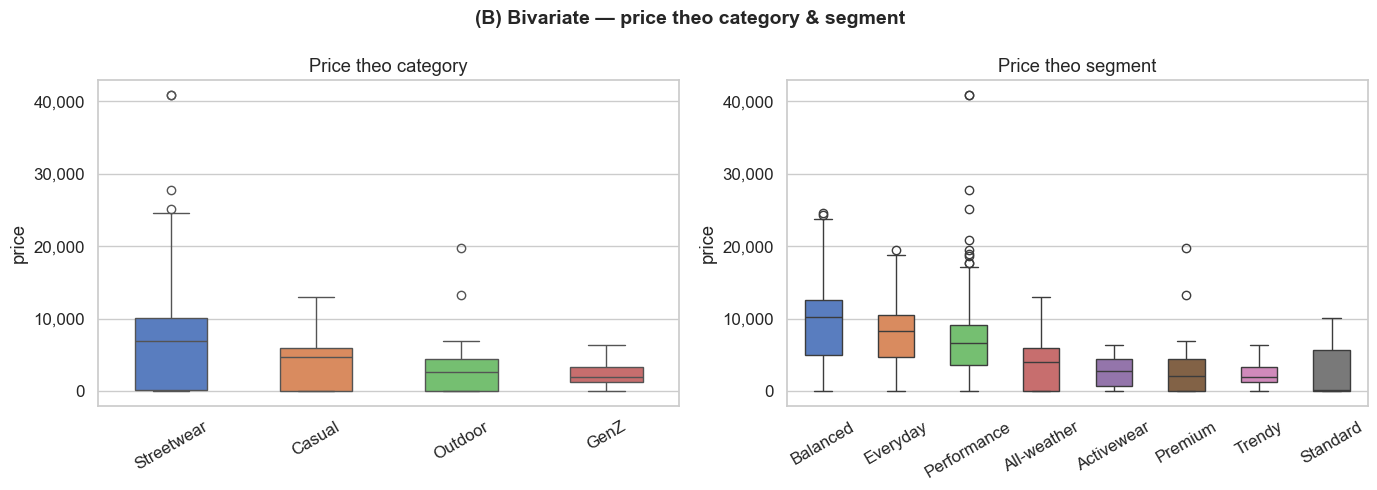

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('(B) Bivariate — price theo category & segment', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['category', 'segment']):
    order = df.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='price', ax=ax, order=order,
                palette='muted', width=0.5)
    ax.set_title(f'Price theo {col}')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(FMT))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Theo Category:**
- `Streetwear` có mức giá **cao nhất** và **biến động lớn nhất**
  (median ~6.000, whisker kéo đến ~22.000, outlier lên đến ~41.000).
- `Casual` và `Outdoor` có mức giá trung bình thấp hơn và phân tán ít hơn.
- `GenZ` có giá **thấp nhất** và phân phối tập trung nhất — phù hợp với
  phân khúc hướng đến người trẻ, nhạy cảm về giá.
**Theo Segment:**
- `Balanced` và `Everyday` có median giá cao nhất (~9.000–11.000).
- `Trendy` và `Standard` có giá thấp nhất và ít biến động.
- `Performance` có nhiều outlier giá cao → một số sản phẩm hiệu suất cao
  được định giá premium đáng kể.

In [ ]:
print("=" * 55)
for group_col in ['category', 'segment']:
    groups = [grp['price'].values for _, grp in df.groupby(group_col)]
    H, p = kruskal(*groups)
    print(f"\nKruskal-Wallis — price theo {group_col.upper()}")
    print(f"   H-statistic = {H:.4f}")
    print(f"   p-value     = {p:.4e}")
    print(f"   Kết luận    : {'Có sự khác biệt có ý nghĩa thống kê' if p < 0.05 else 'Không có sự khác biệt ❌'} (α=0.05)")
print("=" * 55)

NameError: name 'kruskal' is not defined

In [ ]:
def epsilon_squared(H, n, k):
    """
    ε² = (H - k + 1) / (n - k)
    H: Kruskal-Wallis statistic
    n: tổng số quan sát
    k: số nhóm
    Mức độ: nhỏ < 0.04, trung bình < 0.16, lớn >= 0.16
    """
    return (H - k + 1) / (n - k)

n = len(df)
print("=" * 55)
for group_col in ['category', 'segment']:
    groups = [grp['price'].values for _, grp in df.groupby(group_col)]
    k = len(groups)
    H, p = kruskal(*groups)
    eps2 = epsilon_squared(H, n, k)

    if   eps2 >= 0.16: level = "Lớn"
    elif eps2 >= 0.04: level = "Trung bình"
    else:              level = "Nhỏ"

    print(f"\nEffect size — price theo {group_col.upper()}")
    print(f"   ε² = {eps2:.4f}  →  {level}")
print("=" * 55)



Effect size — price theo CATEGORY
   ε² = 0.1666  →  Lớn

Effect size — price theo SEGMENT
   ε² = 0.2526  →  Lớn


In [ ]:
import scikit_posthocs as sp
for group_col in ['category', 'segment']:
    print(f"\n Dunn Post-hoc — {group_col.upper()}")
    dunn = sp.posthoc_dunn(df, val_col='price', group_col=group_col, p_adjust='bonferroni')
    print(dunn.round(4))


 Dunn Post-hoc — CATEGORY
            Casual    GenZ  Outdoor  Streetwear
Casual      1.0000  0.0034      0.0         0.0
GenZ        0.0034  1.0000      1.0         0.0
Outdoor     0.0000  1.0000      1.0         0.0
Streetwear  0.0000  0.0000      0.0         1.0

 Dunn Post-hoc — SEGMENT
             Activewear  All-weather  Balanced  Everyday  Performance  \
Activewear       1.0000       0.0545    0.0000    0.0000       0.0000   
All-weather      0.0545       1.0000    0.0000    0.0000       0.0000   
Balanced         0.0000       0.0000    1.0000    1.0000       0.0003   
Everyday         0.0000       0.0000    1.0000    1.0000       0.0422   
Performance      0.0000       0.0000    0.0003    0.0422       1.0000   
Premium          1.0000       0.0073    0.0000    0.0000       0.0000   
Standard         1.0000       0.5793    0.0000    0.0000       0.0000   
Trendy           1.0000       0.0735    0.0000    0.0000       0.0000   

             Premium  Standard  Trendy  
Activewe

**Insight: Kiểm định thống kê — Price theo Category & Segment**


**Category (ε² = 0.167 — Effect size **Lớn**)**

Kruskal-Wallis xác nhận sự khác biệt giá giữa 4 category **có ý nghĩa thống kê rất cao**
(H=404.27, p≈0).

Post-hoc Dunn test (Bonferroni) cho thấy:

| Cặp so sánh | p-value | Kết luận |
|---|---|---|
| Streetwear vs tất cả | < 0.001 | Khác biệt rõ  |
| Casual vs Outdoor / GenZ | < 0.05 | Khác biệt rõ |
| **GenZ vs Outdoor** | 1.000 | **Không khác biệt** |

→ Xếp hạng giá: **Streetwear >> Casual >> {GenZ ≈ Outdoor}**

`GenZ` và `Outdoor` có mức giá **tương đương nhau**, mặc dù thuộc hai phân khúc thị trường khác nhau.

---

**Segment (ε² = 0.253 — Effect size **Lớn**)**

Sự khác biệt giá giữa 8 segment còn mạnh hơn category (H=614.33, p≈0).
Post-hoc cho thấy 3 nhóm giá rõ ràng:

| Nhóm giá | Segment |
|---|---|
|  **Cao** | `Balanced` ≈ `Everyday` |
|  **Trung bình** | `Performance` |
|  **Thấp** | `Activewear` ≈ `All-weather` ≈ `Standard` ≈ `Premium` ≈ `Trendy` |

>  **Đáng chú ý:** Segment `Premium` có giá **không cao hơn** các segment còn lại
> (p=1.0 với Activewear, Standard, Trendy) — tên gọi "Premium" không phản ánh
> mức giá thực tế trong dataset này.


# Tóm tắt: Data Cleaning & Key Insights — `products`

---

### Các bước xử lý dữ liệu

| Bước | Vấn đề | Xử lý | Tác động |
|------|--------|--------|----------|
| 1 | Kiểm tra ràng buộc `cogs < price` | Xác nhận: **tất cả 2.412 bản ghi** đều thoả | Không xóa hàng |
| 2 | Kiểm tra tính duy nhất `product_id` | Xác nhận: **không có duplicate** | Không xóa hàng |
| 3 | Phát hiện **186 `product_name`** bị trùng (2–3 lần, 426 bản ghi ~17.7%) — chỉ khác nhau ở `price` / `cogs`, hoàn toàn giống về `category`, `segment`, `size`, `color` | Flag bản ghi có `price` lệch > 50% so với median nhóm (**81 bản ghi bất thường**), sau đó giữ 1 bản ghi đại diện mỗi tên | **2.412 → 2.172 hàng** |

> **Dữ liệu đầu ra:** `product_cleaned.csv` — **2.172 sản phẩm**, 8 cột, không có giá trị thiếu.

---

### Key Insights từ EDA

#### 1. Phân phối Price & COGS
- Cả `price` và `cogs` đều **lệch phải mạnh** (skewness > 1) — **không tuân theo phân phối chuẩn** (KS-test p ≈ 0).
- Phần lớn sản phẩm tập trung ở mức giá thấp; một số ít có giá rất cao.
- → Các phân tích tiếp theo cần dùng phương pháp **phi tham số**.

#### 2. Gross Margin (Biên lợi nhuận gộp)
- `price` và `cogs` tương quan **rất mạnh** (Spearman r = **0.981**) — giá vốn chiếm trung bình ~79% giá bán.
- Margin dao động rộng: mean = **26.59%**, std = **15.11%**, min = 5%, max = 50%.
- Phân phối margin **bimodal** (hai cụm rõ): ~5–10% và ~30–50% → chiến lược định giá khác nhau giữa các nhóm sản phẩm.

#### 3. Phân bố Categorical
- **`category`**: Streetwear chiếm ưu thế (**54.7%**) — mất cân bằng đáng kể.
- **`segment`**: 8 phân khúc, phân bố tương đối đa dạng.
- **`size` & `color`**: Phân bố **hoàn toàn đều** (by design) — không phản ánh nhu cầu thực tế.

#### 4. So sánh Price theo Category (Kruskal-Wallis + Post-hoc Dunn)
- Có sự khác biệt có ý nghĩa thống kê (H=404.27, p≈0, **ε² = 0.167 — Large**).
- Xếp hạng giá: **Streetwear >> Casual >> {GenZ ≈ Outdoor}**.

#### 5. So sánh Price theo Segment (Kruskal-Wallis + Post-hoc Dunn)
- Có sự khác biệt có ý nghĩa thống kê (H=614.33, p≈0, **ε² = 0.253 — Large**).
- 3 nhóm giá rõ ràng:
  - **Cao**: `Balanced` ≈ `Everyday`
  - **Trung bình**: `Performance`
  - **Thấp**: `Activewear` ≈ `All-weather` ≈ `Standard` ≈ `Premium` ≈ `Trendy`
- Segment `Premium` **không có giá cao hơn** các segment khác — tên gọi không phản ánh thực tế.
